# LEAP Momentum bootcamp

## Generative Models for Climate — Practical

This notebook walks through Langevin Monte Carlo and score-based diffusion models, from a low-dimensional
toy system up to a conditional sampler for a chaotic dynamical system. It is organized as follows.

| Section | Topic |
|---|---|
| 1 | Langevin dynamics: sampling a known 2D density (double well × Gaussian) |
| 2 | A diffusion model: learning the score of a 2D mixture and sampling from it |
| 3 | A 3D diffusion model for the Lorenz 63 attractor |
| 4 | Application to an inverse problem: conditional sampling for data assimilation |

All the functions and algorithms, including the bits to be filled, are written in separate python modules. This notebook imports and assembles them, and serves as a tool to visualize the results.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import plot
plot.use_latex()  # render all matplotlib text + math through LaTeX

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)

device = "cpu"  # the models are tiny MLPs; CPU is fastest & fully reproducible
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device:", device)

torch 2.12.0 | device: cpu


## Section 1 — Langevin Dynamics

Our target is the Gibbs (Boltzmann) distribution of a 2D potential: the
asymmetric double well in $x$, plus an independent harmonic (Gaussian) trap in
$y$. The target density takes the form

$$p(x,y) \propto e^{-f(x,y)},$$

with

$$f(x, y) = x^4 - 2x^2 + 0.3x + \tfrac12 k\, y^2.$$

Let us first look at the target density itself, before trying to sample from it. It has two wells along $x$, with a Gaussian shape in $y$.

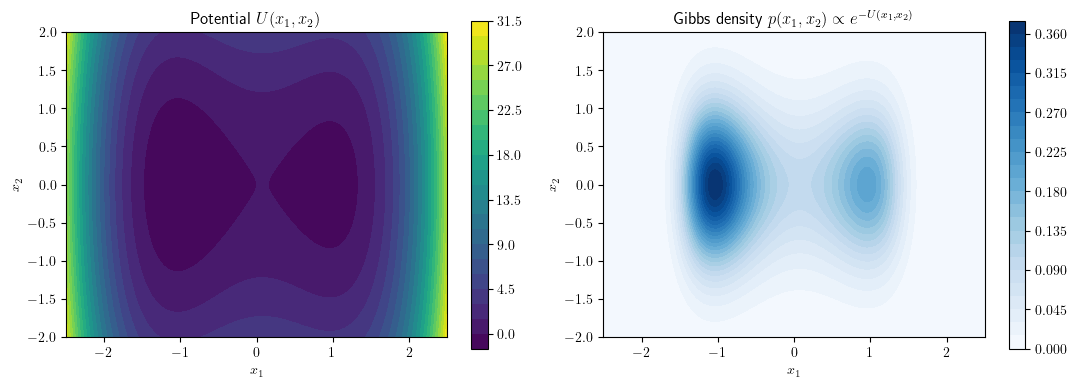

In [2]:
from dynamics import double_well_gaussian_2d as double_well

x_axis = np.linspace(-2.5, 2.5, 300)
y_axis = np.linspace(-2.0, 2.0, 240)
grid_x, grid_y = np.meshgrid(x_axis, y_axis)
grid_points = np.stack([grid_x, grid_y], axis=-1)

potential_grid = double_well.potential(grid_points)
density_grid = double_well.gibbs_density(grid_points)

# The target density, on its own (no samples yet).
plot.potential_and_density_2d(grid_x, grid_y, potential_grid, density_grid)

To draw samples from this density we use the Langevin Monte Carlo Algorithm. This algorithm requires the gradient $\nabla f$, which is here a 2D vector field. The sampling iterations are

$$ x_{k+1} =  x_k - \eta\,\nabla f( x_k)
+ \sqrt{2\eta}\, w_k,
\qquad w_k \sim \mathcal N(0, I_2).$$

Running many independent chains in parallel fills **both** wells; we then overlay
the generated samples on the density to check they agree.

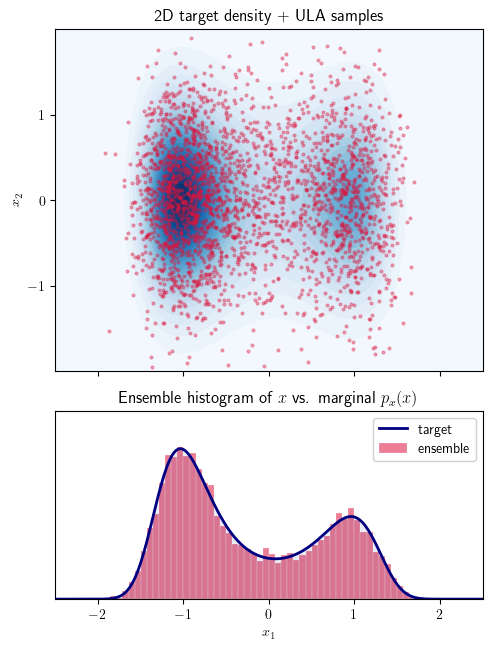

left-well mass: 0.62  right-well mass: 0.38


In [3]:
from sampling.langevin import langevin_sample

# Many independent ULA chains from a broad uniform spread, so BOTH wells fill.
rng = np.random.default_rng(0)
initial_states = rng.uniform([-2.0, -1.5], [2.0, 1.5], size=(8000, 2))
langevin_samples = langevin_sample(double_well.grad_potential, initial_states,
                                   eta=5e-3, n_steps=3000, rng=rng)

# Same 2D-contour + 1D-marginal layout the animation scripts use, drawn once
# at the final ensemble state.
plot.density_marginal_snapshot(
    (grid_x, grid_y, density_grid), x_axis, double_well.x_marginal(x_axis),
    langevin_samples, xlim=(-2.5, 2.5), ylim=(-2.0, 2.0))

left_well_mass = (langevin_samples[:, 0] < 0).mean()
right_well_mass = (langevin_samples[:, 0] > 0).mean()
print(f"left-well mass: {left_well_mass:.2f}  right-well mass: {right_well_mass:.2f}")

## Section 2 — Learning to Sample: a 2D Gaussian Mixture

In Section 1, the analytic expression of the target density was known, which allowed us to compute the Langevin iterations with the potential gradient $\nabla f(x)$.

Generative-modeling aims at learning the data distribution from samples, and to draw new ones, without an analytical model. 

In this section, we learn a diffusion model on a two-dimensional bimodal data distribution.

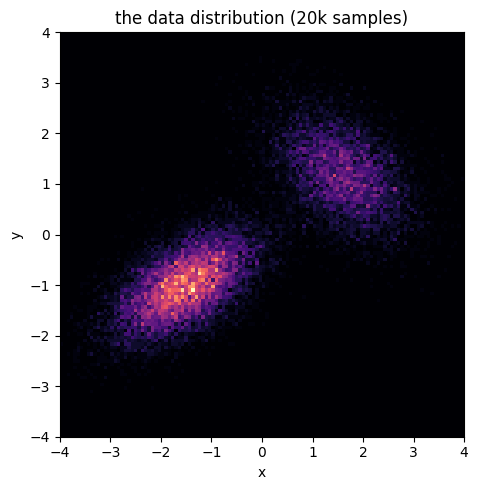

In [23]:
from dynamics import gaussian_mixture_2d as mixture


mixture_data = mixture.sample(20000, rng=np.random.default_rng(0)).astype(np.float32)

plot.samples_2d(mixture_data, title="the data distribution (20k samples)")

**A model for the data.** The point cloud has two well-separated, tilted blobs
of unequal mass, so we model it as a **mixture of two Gaussians**

$$p(x) = w_1\,\mathcal N(x;\mu_1,\Sigma_1) + w_2\,\mathcal N(x;\mu_2,\Sigma_2),
\qquad (w_1,w_2) = (0.65,\,0.35).$$

Being a mixture, it is *exactly samplable* and its **score** is known in closed
form — the responsibility-weighted blend of the two linear scores,

$$\nabla\log p(x) = -\sum_k r_k(x)\,\Sigma_k^{-1}(x-\mu_k),
\qquad r_k(x) = \frac{w_k\,\mathcal N_k(x)}{\sum_j w_j\,\mathcal N_j(x)}.$$

This gives us ground truth to check any learned model against.

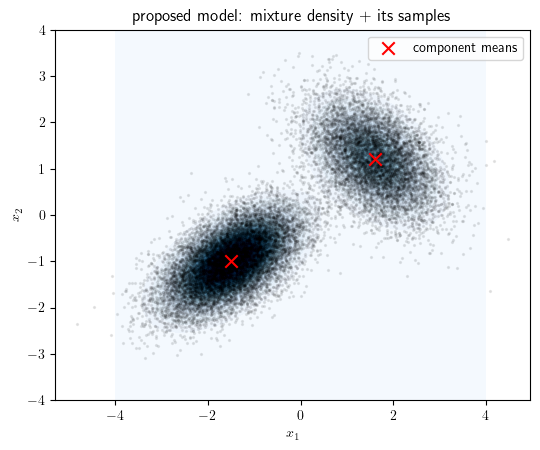

target weights  heavy/light: 0.65 / 0.35
data mass       heavy/light: 0.64 / 0.36


In [5]:
# Analytic mixture density on a square grid covering both blobs.
x_axis = np.linspace(-4.0, 4.0, 240)
grid_x, grid_y = np.meshgrid(x_axis, x_axis)
density_grid = mixture.gibbs_density(np.stack([grid_x, grid_y], axis=-1))

plot.density_and_samples_2d((grid_x, grid_y, density_grid), mixture_data,
                            means=mixture.MEANS,
                            title="proposed model: mixture density + its samples")

heavy_mode_fraction = lambda points: (mixture.responsibilities(points).argmax(-1) == 0).mean()
print(f"target weights  heavy/light: {mixture.WEIGHTS[0]:.2f} / {mixture.WEIGHTS[1]:.2f}")
print(f"data mass       heavy/light: {heavy_mode_fraction(mixture_data):.2f} / "
      f"{1 - heavy_mode_fraction(mixture_data):.2f}")

### Why not just run Langevin here? — a failure mode

We *have* $\nabla\log p$ in closed form, so we could try the Section-1 sampler
directly. But the two components are **far apart**, separated by a deep
low-density valley where the score $\nabla\log p \approx 0$ — a chain gets almost
**no push** across. Within any practical budget it stays trapped in whichever
mode it started in: ULA becomes **metastable**, and its empirical histogram
reflects the *initialization*, not the $0.65/0.35$ target.

(ULA is asymptotically exact, so *enough* steps would converge — but "enough"
grows exponentially with the barrier height.) Let's run the same ULA from a
uniform start and compare the empirical histograms of the **data** and of
**Langevin**, projected onto the axis joining the two modes.

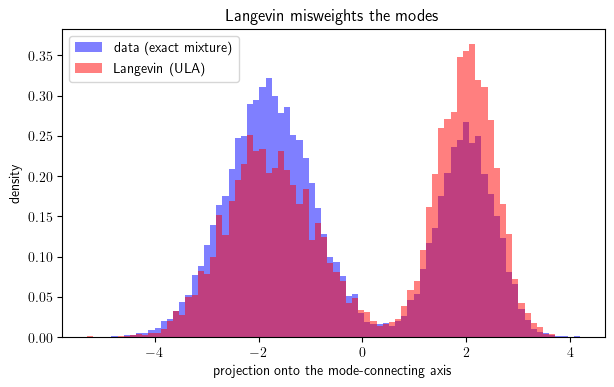

target weights  heavy/light: 0.65 / 0.35
data mass       heavy/light: 0.64 / 0.36
Langevin mass   heavy/light: 0.51 / 0.49


In [6]:
# Project onto the unit axis joining the two component means -> a clean 1D view
# in which the two modes are two separate peaks.
mode_axis = mixture.MEANS[1] - mixture.MEANS[0]
mode_axis = mode_axis / np.linalg.norm(mode_axis)

rng = np.random.default_rng(0)
initial_states = rng.uniform(-4, 4, size=(8000, 2))
langevin_samples = langevin_sample(mixture.grad_potential, initial_states,
                                   eta=3e-3, n_steps=3000, rng=rng)

plot.two_hists(mixture_data @ mode_axis, langevin_samples @ mode_axis,
               labels=("data (exact mixture)", "Langevin (ULA)"),
               title="Langevin misweights the modes")

print(f"target weights  heavy/light: {mixture.WEIGHTS[0]:.2f} / {mixture.WEIGHTS[1]:.2f}")
print(f"data mass       heavy/light: {heavy_mode_fraction(mixture_data):.2f} / "
      f"{1 - heavy_mode_fraction(mixture_data):.2f}")
print(f"Langevin mass   heavy/light: {heavy_mode_fraction(langevin_samples):.2f} / "
      f"{1 - heavy_mode_fraction(langevin_samples):.2f}")

### The fix: a score-based diffusion model

A diffusion model never has to cross the barrier. We define a **noise schedule**
connecting pure noise at $t=0$ to the data at $t=1$,

$$x_t = \mu_t\, x_0 + \sigma_t\,\varepsilon,
\qquad \mu_t^2 + \sigma_t^2 = 1,$$

so that $\mu_0\approx 0,\ \sigma_0\approx 1$ (a single Gaussian blob) and
$\mu_1 = 1,\ \sigma_1 = 0$ (the data). **Generation runs forward in time**: we
start from one Gaussian blob at $t=0$ and integrate the generative SDE up to
$t=1$, where the blob has **split** into both modes in the proportion the score
network learned from data — the relative weight is baked into $s_\theta(x,t)$, not
discovered by hopping.

**Training (denoising score matching).** We fit $s_\theta(x_t,t)\approx
-\varepsilon/\sigma_t$ by minimizing the $\sigma_t^2$-weighted loss
$\|\sigma_t s_\theta + \varepsilon\|^2$. We first standardize the data, since the
noise schedule targets unit variance.

Throughout, the diffusion model runs **forward in
time**: $t=0$ is pure noise and $t=1$ is the data, so generation flows from noise
up to the learned density.

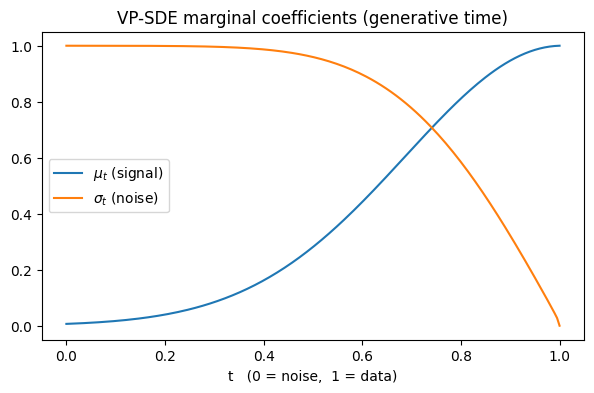

In [ ]:
from sampling.schedule import mu_t, sigma_t

times = torch.linspace(0, 1, 200)
plot.noise_schedule(times, mu_t(times), sigma_t(times))


  0%|          | 0/3000 [00:00<?, ?it/s]


  1%|          | 31/3000 [00:00<00:09, 307.98it/s]


  2%|▏         | 73/3000 [00:00<00:07, 369.87it/s]


  4%|▍         | 113/3000 [00:00<00:07, 381.97it/s]


  5%|▌         | 152/3000 [00:00<00:07, 381.68it/s]

...


 95%|█████████▌| 2857/3000 [00:07<00:00, 405.58it/s]


 97%|█████████▋| 2898/3000 [00:07<00:00, 397.72it/s]


 98%|█████████▊| 2940/3000 [00:07<00:00, 402.35it/s]


 99%|█████████▉| 2981/3000 [00:07<00:00, 398.54it/s]


100%|██████████| 3000/3000 [00:07<00:00, 396.43it/s]

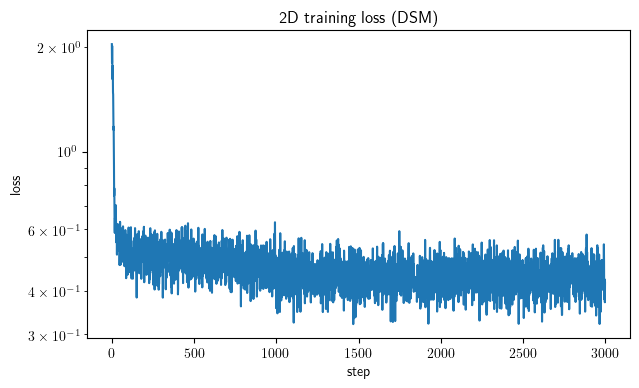

In [8]:
from learning.networks import ScoreNet2D
from learning.training import train_score_model

# Standardize per-dimension (the noise schedule targets unit variance).
data_mean, data_std = mixture_data.mean(0), mixture_data.std(0)
mixture_data_standardized = (mixture_data - data_mean) / data_std

score_model = ScoreNet2D().to(device)
score_model, losses = train_score_model(score_model, mixture_data_standardized,
                                        n_epochs=3000, batch_size=512, lr=1e-3)

plot.loss_curve(losses, title="2D training loss (DSM)", log=True)

**Reading the field.** At the data end ($t\approx1$) the network should recover
the *data* score $\nabla\log p$: arrows point *uphill in probability*, flowing
into the two Gaussian blobs and away from the low-density valley between them. We
draw each arrow as a unit-length **direction** colored by magnitude, so the
geometry stays readable even where the score is large. The analytic field (left)
is the closed-form mixture score; the learned one (right) is what denoising score
matching recovered.

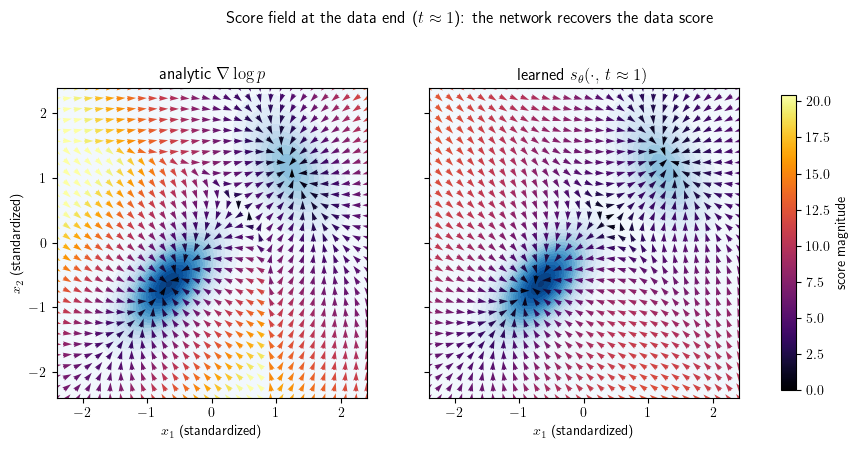

In [9]:
plot.score_fields(score_model, mixture.score, mixture.gibbs_density,
                  data_mean, data_std)

**Across noise levels.** The score depends on *how noisy* its input is. Here we
sweep the **added-noise level $\sigma$** directly (rather than time): the noised
density $p_\sigma$ is the data blurred by a Gaussian of width $\sigma$ (and shrunk
by $\mu=\sqrt{1-\sigma^2}$). At small $\sigma$ the field shows the two-basin
structure of the data score; as $\sigma$ grows the two blobs contract and **merge
into a single Gaussian**, and the learned field collapses to one inward pull
toward the origin. This merging at high noise is exactly what lets generation
start from a single blob and avoid the barrier that trapped Langevin above.

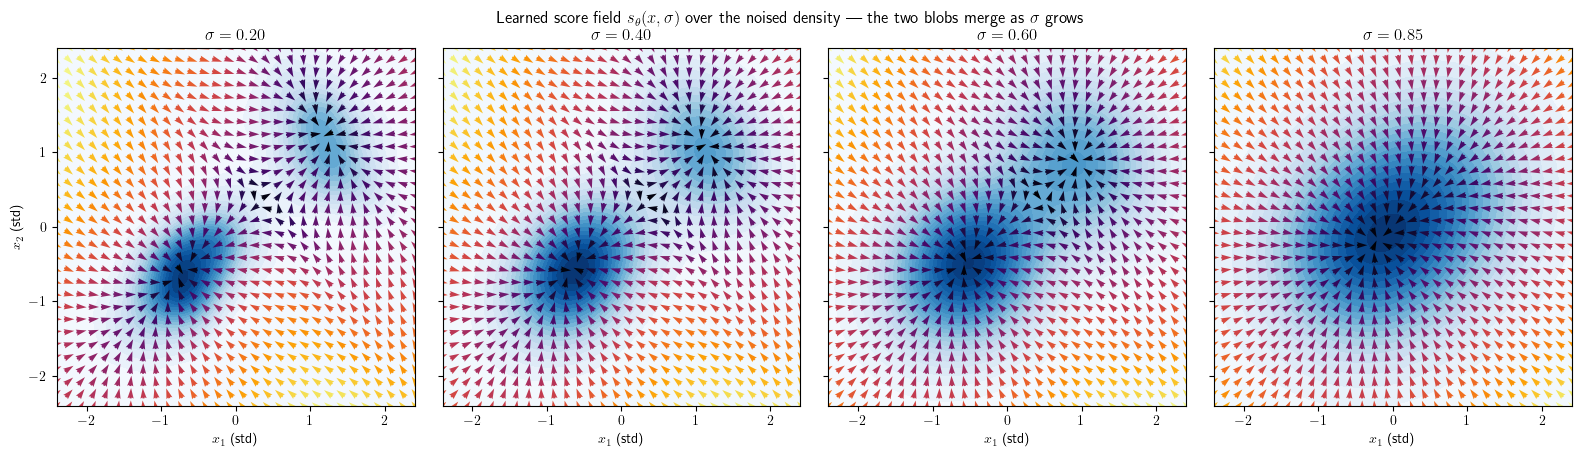

In [10]:
plot.field_across_noise(score_model, mixture_data_standardized,
                        sigma_levels=[0.2, 0.4, 0.6, 0.85])

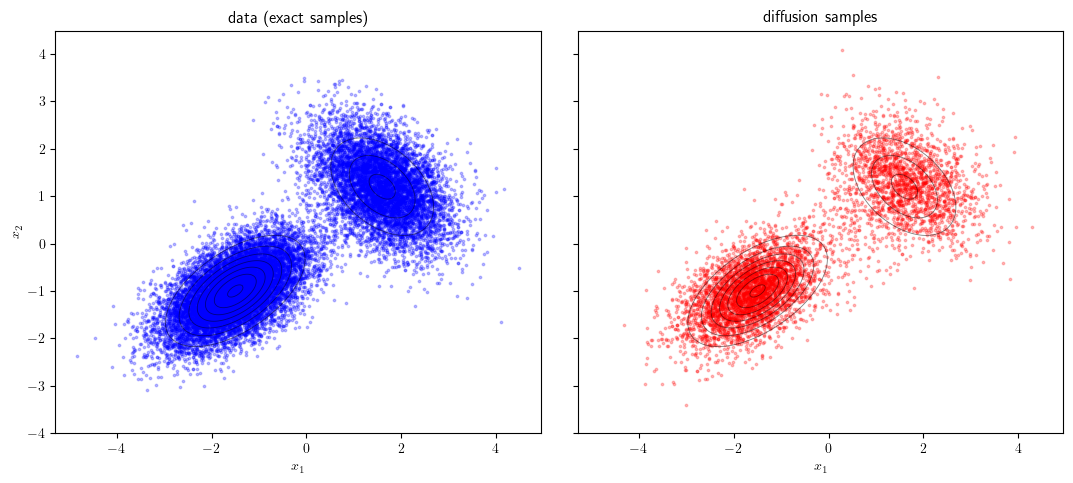

target weights  heavy/light: 0.65 / 0.35
data mass       heavy/light: 0.64 / 0.36
model mass      heavy/light: 0.67 / 0.33


In [11]:
from sampling.diffusion_sampler import generate_samples

# Generate by integrating the generative SDE forward in time, then un-standardize.
generated_samples = generate_samples(score_model, n_samples=6000, dim=2,
                                      n_steps=1000, seed=0)
generated_samples = generated_samples.cpu().numpy() * data_std + data_mean

plot.samples_comparison_2d((grid_x, grid_y, density_grid), mixture_data,
                           generated_samples,
                           titles=("data (exact samples)", "diffusion samples"))

generated_heavy_fraction = heavy_mode_fraction(generated_samples)
print(f"target weights  heavy/light: {mixture.WEIGHTS[0]:.2f} / {mixture.WEIGHTS[1]:.2f}")
print(f"data mass       heavy/light: {heavy_mode_fraction(mixture_data):.2f} / "
      f"{1 - heavy_mode_fraction(mixture_data):.2f}")
print(f"model mass      heavy/light: {generated_heavy_fraction:.2f} / "
      f"{1 - generated_heavy_fraction:.2f}")

**Why diffusion gets it right.** The generative process never has to cross the
barrier. Run forward in time, it **starts from a single Gaussian blob** at $t=0$
and **splits** it into both modes by $t=1$, in the proportion the score network
learned from data — the relative weight is baked into $s_\theta(x,t)$ at every
noise level. This robustness to separated, unequally-weighted modes is a core
reason to prefer score-based diffusion over plain Langevin on multimodal targets.

## Section 3 — Lorenz '63 Diffusion Model

We now scale up to 3D. The **Lorenz '63** system is chaotic; points along a long
trajectory sample its invariant measure — the two-winged *butterfly attractor*.
We train a `ScoreNet3D` on this point cloud and then **generate** new states by
running the diffusion model forward in time (from noise at $t=0$ to data at
$t=1$). Good samples should re-trace the butterfly.

training cloud: (22000, 3)



  0%|          | 0/4000 [00:00<?, ?it/s]


  0%|          | 12/4000 [00:00<00:35, 112.17it/s]


  1%|          | 25/4000 [00:00<00:32, 120.51it/s]


  1%|          | 38/4000 [00:00<00:33, 118.33it/s]

...


 99%|█████████▊| 3942/4000 [00:24<00:00, 168.67it/s]


 99%|█████████▉| 3959/4000 [00:24<00:00, 168.23it/s]


 99%|█████████▉| 3977/4000 [00:24<00:00, 169.64it/s]


100%|█████████▉| 3994/4000 [00:24<00:00, 167.94it/s]


100%|██████████| 4000/4000 [00:24<00:00, 162.76it/s]

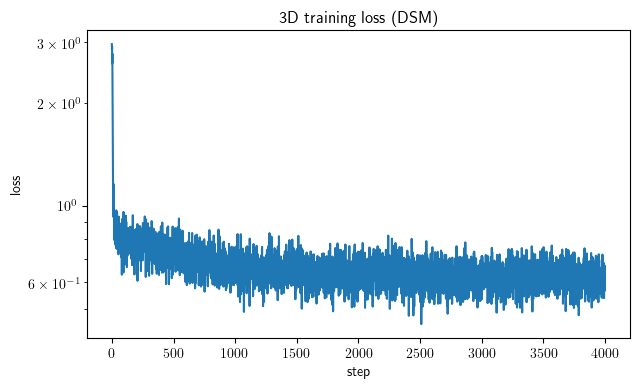

In [12]:
from dynamics.lorenz import simulate_attractor
from learning.networks import ScoreNet3D

lorenz_data = simulate_attractor(n_steps=25000, dt=0.01, burn_in=3000).astype(np.float32)
lorenz_mean, lorenz_std = lorenz_data.mean(0), lorenz_data.std(0)
lorenz_data_standardized = (lorenz_data - lorenz_mean) / lorenz_std
print("training cloud:", lorenz_data.shape)

score_model_3d = ScoreNet3D().to(device)
score_model_3d, losses_3d = train_score_model(score_model_3d, lorenz_data_standardized,
                                              n_epochs=4000, batch_size=512, lr=1e-3)
plot.loss_curve(losses_3d, title="3D training loss (DSM)", log=True)

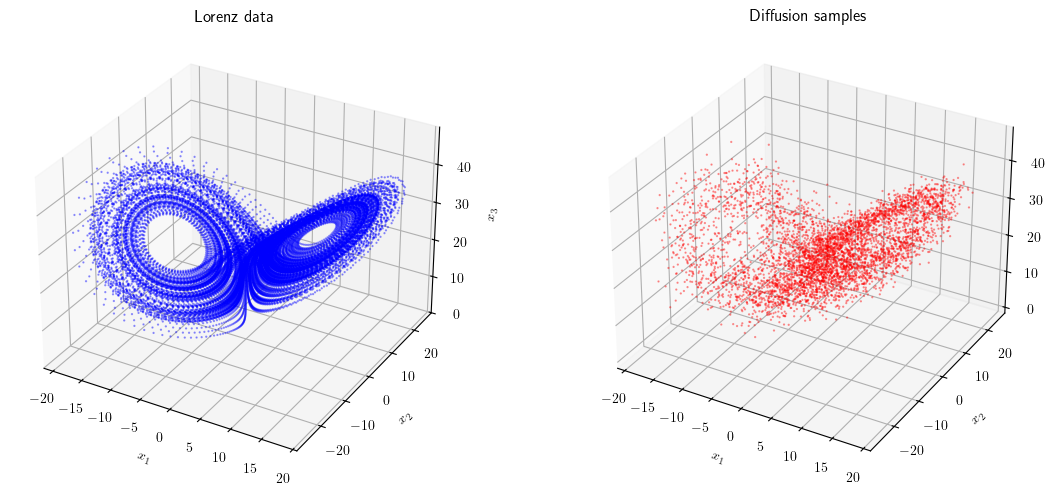

In [13]:
generated_standardized = generate_samples(score_model_3d, n_samples=5000, dim=3,
                                          n_steps=1000, seed=0)
generated_states = generated_standardized.cpu().numpy() * lorenz_std + lorenz_mean

plot.comparison_3d(lorenz_data, generated_states)

## Section 4 — Inverse Problem: Conditional Sampling

Finally, a data-assimilation flavored task. We observe **only the z-component**
of a hidden Lorenz state, through a noisy linear sensor

$$y = Hx + \nu,\quad H=[0,0,1],\quad \nu\sim\mathcal N(0,\sigma_{\text{obs}}^2).$$

We want the **posterior** $p(x\mid y)$. By Bayes, its score is just a sum:

$$\nabla_x\log p(x\mid y) = \underbrace{\nabla_x\log p(x)}_{s_\theta\ (\text{Section 3})}
+ \underbrace{\nabla_x\log p(y\mid x)}_{\text{closed-form Gaussian}}.$$

We plug this posterior score into the **same forward-time generative sampler**.
The butterfly attractor is left–right symmetric about the $z$-axis: for a given
$z$ value, states with that altitude exist on **both wings**. So $z$ alone cannot
tell us which lobe the truth is on, and the posterior over the full 3D state is
**bimodal** — the ensemble should split into the two wings, discriminated by the
sign of $x$.

In [14]:
from sampling.inverse_problem import ObservationOperator, conditional_sample

# Pick a truth state on the attractor and synthesize a noisy z-observation.
# Sampling from the trajectory keeps the observation consistent with the prior.
truth = np.array([-17.19, -7.62, 46.51])                 # shape (3,)
observation_noise_std = 1.0                   # physical units
rng = np.random.default_rng(42)
z_obs = truth[2] + observation_noise_std * rng.standard_normal()
print(f"truth state: {truth.round(2)}   observed z: {z_obs:.2f}")

# The sampler works in standardized space, so standardize both y and sigma_obs
# along the z-coordinate (last column).
observation = ObservationOperator(sigma_obs=observation_noise_std / lorenz_std[2])
y_standardized = torch.tensor([(z_obs - lorenz_mean[2]) / lorenz_std[2]],
                              dtype=torch.float32)

posterior_standardized = conditional_sample(score_model_3d, y_standardized, observation,
                                            n_samples=2000, dim=3, n_steps=1000, seed=0)
posterior_samples = posterior_standardized.cpu().numpy() * lorenz_std + lorenz_mean

# Sign of x is the natural wing discriminator for the Lorenz butterfly.
wing_mask = posterior_samples[:, 0] > 0
print(f"posterior mean (xyz): {posterior_samples.mean(0).round(2)}")
print(f"posterior std  (xyz): {posterior_samples.std(0).round(2)}")
print(f"positive-x wing fraction: {wing_mask.mean():.2f}  "
      "(a well-calibrated posterior populates both lobes)")

truth state: [-17.19  -7.62  46.51]   observed z: 46.81


posterior mean (xyz): [ 2.4   1.87 45.85]
posterior std  (xyz): [13.86  6.77  0.7 ]
positive-x wing fraction: 0.58  (a well-calibrated posterior populates both lobes)


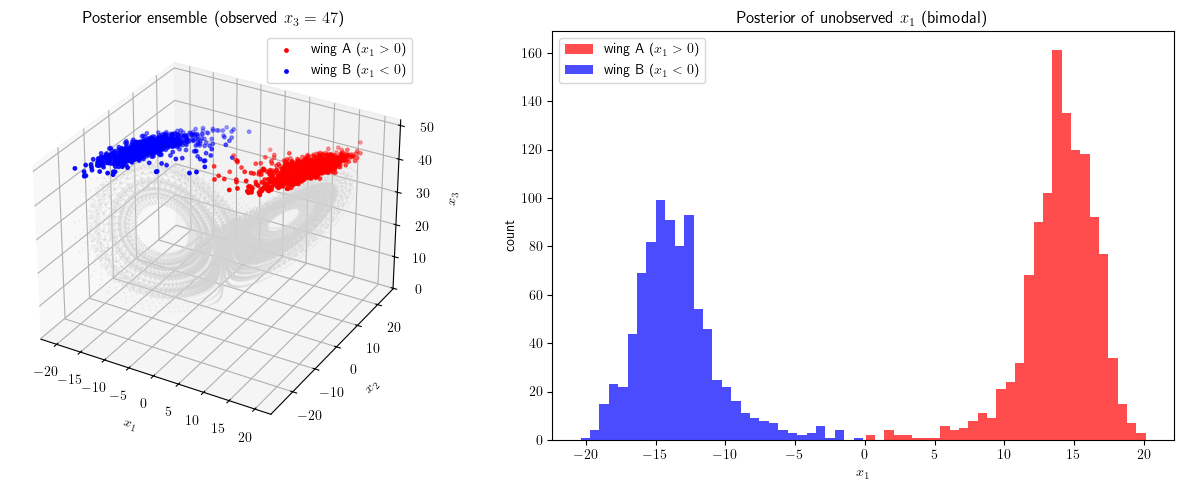

In [15]:
plot.posterior_ensemble(lorenz_data, posterior_samples, wing_mask, z_obs)

**Takeaway.** A single diffusion prior, trained once on the attractor, was
re-used to solve an inverse problem *without retraining*: we only added a
closed-form likelihood score. The posterior concentrates around the observed
$z$ while expressing genuine uncertainty about the unobserved $x,y$ — the
ensemble splits into both lobes of the butterfly, because $z$ alone cannot
distinguish them.

## Section 5 — Cyclic Data Assimilation

Section 4 used a *single* noisy observation. In real data assimilation we get a
**stream** of observations along a trajectory and we want to keep tracking the
truth as it evolves. We now run that loop, but with a posterior score designed
to be a **strict improvement over the classical 3D-Var baseline**:

1. **Observe** $y_k = H\,x_{\text{truth}}(t_k) + \nu$ at cycle times
   $t_k = k\,\Delta t$. Here we change the observation operator from Section 4:
   we observe the **second and third coordinates** and leave $x_1$ hidden,
   $$
   H = \begin{pmatrix}0 & 1 & 0\\ 0 & 0 & 1\end{pmatrix}.
   $$
2. **Analyze**. The forecast ensemble's mean $x_b$, the climatological prior
   covariance $B$ and the observation noise covariance $R$ define a **3D-Var
   posterior** $\mathcal N(x_a, P_a)$ with
   $$
   P_a^{-1} = B^{-1} + H^\top R^{-1} H, \qquad x_a = x_b + K(y_k - H x_b),
   $$
   whose score is $P_a^{-1}(x_a - x)$. We plug that **exact Gaussian guidance**
   into `conditional_sample` together with the diffusion score $s_\theta(x,t)$:
   $$
   \nabla_x \log p(x \mid y_k) \;=\; s_\theta(x, t)
   \;+\; \underbrace{w_b\,B^{-1}(x_b - x) + w_y\,H^\top R^{-1}(y_k - Hx)}_{=\,P_a^{-1}(x_a - x)\text{ when }w_b = w_y = 1}.
   $$
   With $w_b = w_y = 1$ the Gaussian piece is **exactly** the 3D-Var posterior,
   so turning off $s_\theta$ recovers 3D-Var verbatim; turning $s_\theta$ on
   adds an **attractor regularizer** on top -- a strict improvement when the
   diffusion prior is informative. Smaller weights widen the Gaussian (a
   stability knob for stiff $R$, where the 3D-Var precision has eigenvalues
   $\sim 1/R$).
3. **Forecast**: propagate every analysis member through the Lorenz dynamics
   for $\Delta t$ to produce the next cycle's background ensemble.

Because $x_1$ is hidden, the posterior at each cycle is **bimodal in $x_1$**:
both wings of the butterfly contain states consistent with $(x_2, x_3)$, so the
analysis ensemble should split across the two lobes. The forecast then evolves
that bimodal cloud, and the next observation re-tightens it -- a structure
3D-Var by itself cannot represent.

In [16]:
from sampling.inverse_problem import ObservationOperator, conditional_sample
from sampling.var3d import climatological_B
from sampling.cyclic_da_setup import H_PHYS, OBS_IDX, build_truth_and_obs
from dynamics.lorenz import Lorenz63, integrate_trajectories

# Make this section reproducible end-to-end. The same `build_truth_and_obs`
# helper drives `scripts/lorenz_cyclic_da.py`, `scripts/lorenz_cyclic_3dvar.py`
# and `scripts/lorenz_cyclic_compare.py` -- so the truth and observation
# sequences below are bit-identical across all four call sites.
np.random.seed(0)
torch.manual_seed(0)

# Observation operator: select (x2, x3); x1 stays hidden.
H_phys = H_PHYS.astype(np.float32)
obs_indices = list(OBS_IDX)

# Physical-space noise std (same on both observed components).
observation_noise_std = 0.1

# Cycle schedule.
n_cycles = 20
dt_cycle = 1.0

# Shared truth + obs builder (Lorenz spin-up + noisy y = H truth + nu).
cycle_times, truth, y_obs = build_truth_and_obs(
    n_cycles, dt_cycle, observation_noise_std, seed=0)
dynamics = Lorenz63()
print("truth shape :", truth.shape, " y_obs shape :", y_obs.shape)

# --- 3D-Var building blocks, all in the score model's standardized space ---
# With z = (x - mean) / std and y_std_i = (y_i - mean_{OBS}_i) / std_{OBS}_i,
# the obs equation in z-space is y_std = H_phys @ z + nu_std with
# nu_std ~ N(0, diag((sigma_obs / std_{OBS})**2)). Climatological B in z-space
# is the sample covariance of standardized data (= the correlation matrix of
# the physical climatology).
std64 = lorenz_std.astype(np.float64)
R_std = np.diag((observation_noise_std / std64[obs_indices]) ** 2)
B_std = climatological_B((lorenz_data.astype(np.float64) - lorenz_mean) / std64)
print("diag(B_std) =", np.diag(B_std).round(3))
print("diag(R_std) =", np.diag(R_std).round(5))

observation_op = ObservationOperator(
    H=torch.as_tensor(H_phys),
    sigma_obs=float(np.sqrt(R_std.diagonal().mean())),
)


truth shape : (20, 3)  y_obs shape : (20, 2)
diag(B_std) = [1. 1. 1.]
diag(R_std) = [0.00012 0.00013]


In [17]:
# Initial background ensemble: unconditional climatology samples from Section 3.
# It is broad -- "we only know the state is somewhere on the attractor".
ensemble_size = 64
n_sample_steps = 1000   # matches Section 4 / scripts/lorenz_cyclic_da.py

# The 3D-Var precision has eigenvalues ~ 1/R, so the exact guidance (weight=1)
# is too stiff for n_sample_steps=1000 at sigma_obs=0.1. Reducing the weights
# widens the Gaussian (smaller precision) -- stability knob. With weight=1 the
# Gaussian guidance exactly matches the 3D-Var posterior; small weights keep
# the 3D-Var *shape* (covariance proportional to P_a, mean still x_a) while
# letting the diffusion score do relatively more attractor regularization.
weight_bg = 1e-2
weight_obs = 1e-2

bg0_standardized = generate_samples(score_model_3d, n_samples=ensemble_size,
                                    dim=3, n_steps=500, seed=0)
background_phys = bg0_standardized.cpu().numpy() * lorenz_std + lorenz_mean

background = np.zeros((n_cycles, ensemble_size, 3))
analysis = np.zeros((n_cycles, ensemble_size, 3))
sub_t = np.linspace(0.0, dt_cycle, 51)   # forecast sub-steps between cycles

for k in range(n_cycles):
    background[k] = background_phys

    # Standardize this cycle's observation and the ensemble-mean forecast.
    y_standardized = (y_obs[k] - lorenz_mean[obs_indices]) / lorenz_std[obs_indices]
    x_b_standardized = (background_phys.mean(axis=0) - lorenz_mean) / lorenz_std

    # Analyze: the Gaussian guidance is a scaled 3D-Var posterior; the diffusion
    # score s_theta adds attractor regularization on top -> a strict improvement
    # over 3D-Var by construction when the regularizer is informative.
    analysis_standardized = conditional_sample(
        score_model_3d, y=y_standardized, observation=observation_op,
        background=x_b_standardized, B=B_std, R=R_std,
        weight_bg=weight_bg, weight_obs=weight_obs,
        n_samples=ensemble_size, dim=3, n_steps=n_sample_steps, seed=k,
    )
    analysis_phys = analysis_standardized.cpu().numpy() * lorenz_std + lorenz_mean
    analysis[k] = analysis_phys

    # Forecast: propagate every analysis member through Lorenz for dt_cycle.
    if k < n_cycles - 1:
        background_phys = integrate_trajectories(
            dynamics.dynamics, analysis_phys, sub_t)[:, -1, :]

# Bundle diagnostics into the dict the plot.cyclic_da helpers consume.
res = {
    "times": cycle_times,
    "truth": truth,
    "y_obs": y_obs,
    "background": background,
    "analysis": analysis,
    "rmse_a": np.sqrt(((analysis.mean(1) - truth) ** 2).mean(1)),
    "rmse_b": np.sqrt(((background.mean(1) - truth) ** 2).mean(1)),
    "spread_a": analysis.std(1).mean(1),
    "spread_b": background.std(1).mean(1),
}
print(f"mean background RMSE : {res['rmse_b'].mean():.3f}")
print(f"mean analysis  RMSE  : {res['rmse_a'].mean():.3f}")
print(f"mean analysis spread : {res['spread_a'].mean():.3f}")


mean background RMSE : 3.735
mean analysis  RMSE  : 0.771
mean analysis spread : 1.250


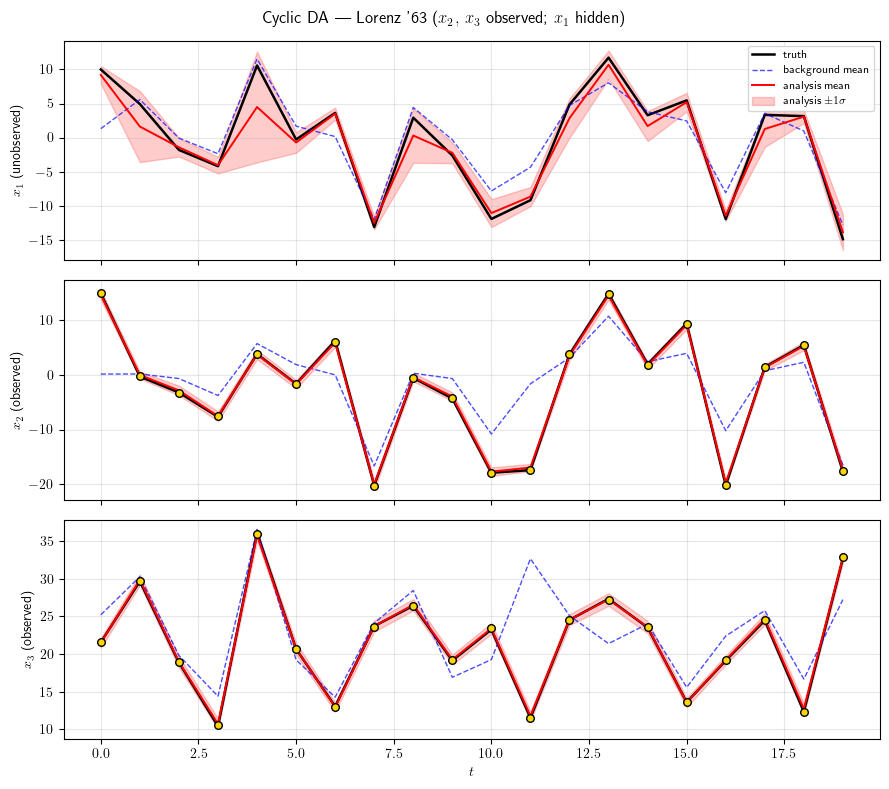

In [18]:
plot.cyclic_da.time_series(res)

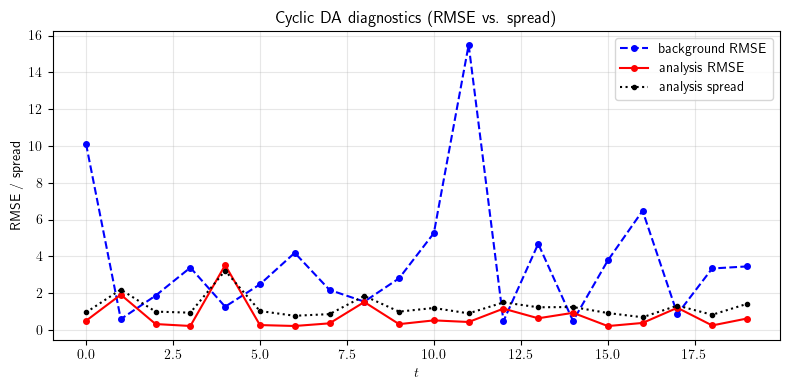

In [19]:
plot.cyclic_da.rmse(res)

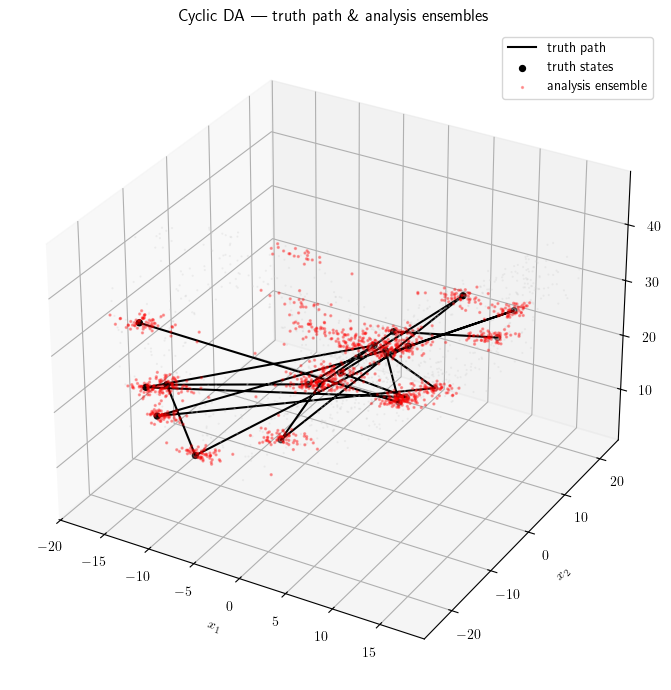

In [20]:
plot.cyclic_da.attractor(res, lorenz_data)

**Takeaway, cyclic DA.** With $(x_2, x_3)$ observed but $x_1$ hidden, the
posterior at each cycle is bimodal in $x_1$: both lobes of the butterfly
contain states consistent with the observation. You can see this directly:

* the $x_1$ panel of the time-series plot has no observation markers, and the
  ensemble spread there is much larger than on the $x_2$ / $x_3$ panels;
* on cycles where the truth sits firmly in one wing, the ensemble mean of
  $x_1$ is pulled toward $0$ because half of the members live in the other
  wing -- an inflated mean-state RMSE that is **information**, not a bug;
* the 3D scatter shows the analysis cloud populating **both wings** at each
  cycle, threaded along the truth path.

The cycling itself is just: re-use the same `conditional_sample` from
Section 4 at each step, propagate the analysis members forward through the
Lorenz dynamics between observations, repeat. The diffusion prior trained once
in Section 3 carries the whole experiment.


### Comparison with the 3D-Var baseline

We now run the classical 3D-Var update on the **same** truth trajectory and the
**same** noisy observations (`cycle_times, truth, y_obs` built once above by
`build_truth_and_obs`). 3D-Var uses a static Gaussian prior $\mathcal{N}(x_b, B)$
with $B$ = sample covariance of the Lorenz climatology, propagated by the
nonlinear Lorenz dynamics between cycles. Overlaying the two analysis RMSE
curves isolates the contribution of the diffusion prior -- everything else
(truth, observations, observation operator, cycle schedule, $B$, $R$) is
identical.


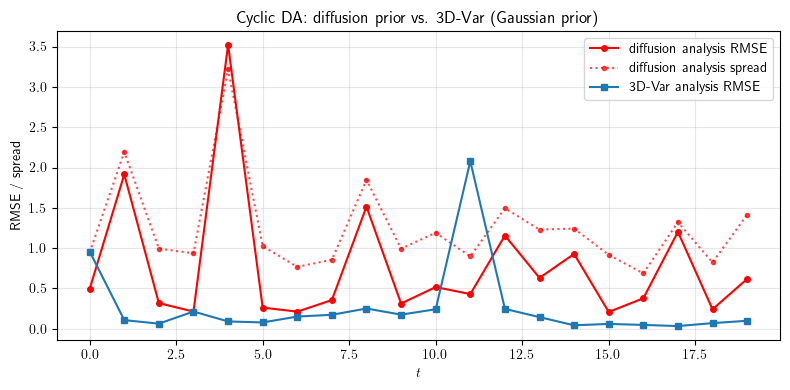

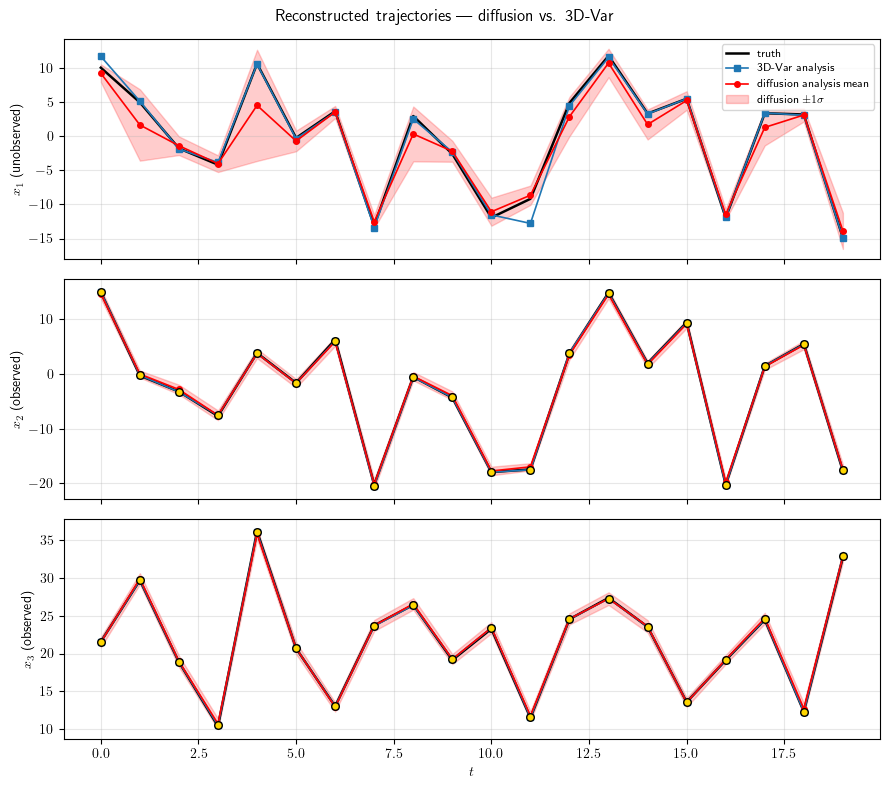

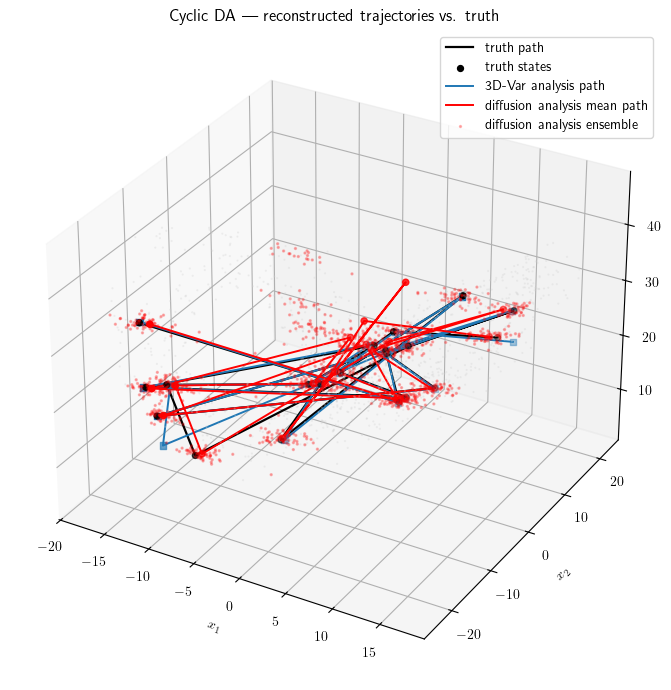

3D-Var      mean analysis RMSE : 0.266
Diffusion   mean analysis RMSE : 0.771  (spread 1.250)


In [21]:
from sampling.var3d import run_cyclic_3dvar

# 3D-Var lives in physical coordinates, so use the physical B and R directly.
B_phys = climatological_B(lorenz_data)
R_phys = observation_noise_std ** 2 * np.eye(H_phys.shape[0])

res_3dvar = run_cyclic_3dvar(
    truth=truth, y_obs=y_obs, cycle_times=cycle_times,
    H=H_phys.astype(np.float64), R=R_phys, B=B_phys,
    dynamics=dynamics.dynamics,
    x_b0=lorenz_data.mean(0), n_substeps=50, verbose=False,
)

# Three overlays on the same (truth, y_obs) data:
#  - per-cycle analysis RMSE,
#  - per-component reconstructed trajectories,
#  - 3D plot of both paths through the attractor.
plot.cyclic_da.compare_rmse(res, res_3dvar)
plot.cyclic_da.compare_time_series(res, res_3dvar)
plot.cyclic_da.compare_attractor(res, res_3dvar, lorenz_cloud=lorenz_data)

print(f"3D-Var      mean analysis RMSE : {res_3dvar['rmse_a'].mean():.3f}")
print(f"Diffusion   mean analysis RMSE : {res['rmse_a'].mean():.3f}  "
      f"(spread {res['spread_a'].mean():.3f})")
